# Лабораторная работа №6 — Условный экстремум
**Студент:** Илюхин Илья | **Группа:** ИУ5-66Б | **Вариант:** 6

**Цель:** исследовать необходимые и достаточные условия существования условного экстремума функции с ограничениями-неравенствами.


## 0. Постановка задачи (вариант 6, задание 1.6)

Найти экстремум функции:
$$f(x) = (x_1^2 - x_1)^4 + (x_2 + 2)^2 - 10 \to \text{extr}$$

при ограничениях-неравенствах:
$$g_1(x) = x_1^2 - x_2^2 - 1 \le 0$$
$$g_2(x) = -x_1 \le 0 \quad (x_1 \ge 0)$$
$$g_3(x) = -x_2 \le 0 \quad (x_2 \ge 0)$$

Множество допустимых решений: $X = \{x \mid x_1 \ge 0,\ x_2 \ge 0,\ x_1^2 - x_2^2 \le 1\}$.

### Классическая функция Лагранжа
$$L(x, \lambda) = f(x) + \lambda_1 g_1(x) + \lambda_2 g_2(x) + \lambda_3 g_3(x)$$
$$= (x_1^2-x_1)^4 + (x_2+2)^2 - 10 + \lambda_1(x_1^2-x_2^2-1) - \lambda_2 x_1 - \lambda_3 x_2$$

### ККТ-условия (необходимые условия 1-го порядка для минимума)
1. $\dfrac{\partial L}{\partial x_1} = 4(x_1^2-x_1)^3(2x_1-1) + 2\lambda_1 x_1 - \lambda_2 = 0$
2. $\dfrac{\partial L}{\partial x_2} = 2(x_2+2) - 2\lambda_1 x_2 - \lambda_3 = 0$
3. Двойственная допустимость (мин): $\lambda_1, \lambda_2, \lambda_3 \ge 0$
4. Прямая допустимость: $g_j(x) \le 0$
5. Дополняющая нежёсткость: $\lambda_j g_j(x) = 0$


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize, fsolve
from sympy import *
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)


## 1. Символьные вычисления (sympy)
Вычислим частные производные функции Лагранжа аналитически.


In [2]:
x1, x2, l1, l2, l3 = symbols('x1 x2 lambda1 lambda2 lambda3', real=True)

f_sym  = (x1**2 - x1)**4 + (x2 + 2)**2 - 10
g1_sym = x1**2 - x2**2 - 1
g2_sym = -x1
g3_sym = -x2

L_sym = f_sym + l1*g1_sym + l2*g2_sym + l3*g3_sym

dL_x1 = diff(L_sym, x1)
dL_x2 = diff(L_sym, x2)

print('∂L/∂x1 =', dL_x1)
print('∂L/∂x2 =', dL_x2)


∂L/∂x1 = 2*lambda1*x1 - lambda2 + (8*x1 - 4)*(x1**2 - x1)**3
∂L/∂x2 = -2*lambda1*x2 - lambda3 + 2*x2 + 4


## 2. Нахождение стационарных точек
Перебираем 8 комбинаций активности ограничений (для каждого g_j: либо g_j=0 активно, либо λ_j=0). Решаем систему ККТ-условий для каждой комбинации.


In [3]:
# Функции для численных вычислений
def f_num(x):  return (x[0]**2 - x[0])**4 + (x[1] + 2)**2 - 10
def g1(x): return x[0]**2 - x[1]**2 - 1
def g2(x): return -x[0]
def g3(x): return -x[1]

def dL_dx1_num(x, lam):
    return 4*(x[0]**2-x[0])**3*(2*x[0]-1) + 2*lam[0]*x[0] - lam[1]
def dL_dx2_num(x, lam):
    return 2*(x[1]+2) - 2*lam[0]*x[1] - lam[2]

candidates = []

# ── Случай A: λ1=0, λ2=0, g3=0 (x2=0) ───────────────────────────────────
# dL/dx1 = 4(x1²-x1)³(2x1-1) = 0  → x1 ∈ {0, 0.5, 1}
# dL/dx2 = 2(x2+2) - λ3 = 0       → λ3 = 4
for x1v in [0.0, 0.5, 1.0]:
    x = np.array([x1v, 0.0])
    lam = np.array([0.0, 0.0, 4.0])
    feasible = g1(x) <= 1e-9 and g2(x) <= 1e-9 and g3(x) <= 1e-9
    dual_ok  = all(l >= -1e-9 for l in lam)
    cs_ok    = (abs(lam[0]*g1(x)) < 1e-9 and
                abs(lam[1]*g2(x)) < 1e-9 and
                abs(lam[2]*g3(x)) < 1e-9)
    stat_ok  = (abs(dL_dx1_num(x, lam)) < 1e-8 and
                abs(dL_dx2_num(x, lam)) < 1e-8)
    if feasible and dual_ok and cs_ok and stat_ok:
        candidates.append({'x1': x1v, 'x2': 0.0,
                            'λ1': lam[0], 'λ2': lam[1], 'λ3': lam[2],
                            'f(x)': round(f_num(x), 6),
                            'Случай': 'λ1=0,λ2=0,g3=0'})

# ── Случай B: g1=0, λ2=0, λ3=0 (на кривой x1²-x2²=1, x1>1, x2>0) ──────
# λ1 = (x2+2)/x2, 4(x1²-x1)³(2x1-1) + 2λ1·x1 = 0 — решаем численно
def equations_B(vars_):
    x1v, x2v = vars_
    lam1 = (x2v + 2) / x2v if x2v != 0 else 1e9
    eq1 = 4*(x1v**2-x1v)**3*(2*x1v-1) + 2*lam1*x1v
    eq2 = x1v**2 - x2v**2 - 1
    return [eq1, eq2]

for x1_start in np.linspace(1.01, 3, 15):
    for x2_start in np.linspace(0.1, 3, 10):
        try:
            sol = fsolve(equations_B, [x1_start, x2_start], full_output=True)
            if sol[2] == 1:  # converged
                sv = sol[0]
                x1v, x2v = sv
                if x1v > 0 and x2v > 0.01:
                    lam1 = (x2v+2)/x2v
                    lam = np.array([lam1, 0.0, 0.0])
                    x = np.array([x1v, x2v])
                    if (lam1 >= -1e-6 and
                        abs(g1(x)) < 1e-6 and g2(x) <= 1e-6 and g3(x) <= 1e-6 and
                        abs(dL_dx1_num(x,lam)) < 1e-4 and abs(dL_dx2_num(x,lam)) < 1e-4):
                        pt = {'x1': round(x1v,6), 'x2': round(x2v,6),
                              'λ1': round(lam1,4), 'λ2': 0.0, 'λ3': 0.0,
                              'f(x)': round(f_num(x),6), 'Случай': 'g1=0,λ2=0,λ3=0'}
                        if not any(abs(c['x1']-pt['x1'])<1e-3 and
                                   abs(c['x2']-pt['x2'])<1e-3 for c in candidates):
                            candidates.append(pt)
        except:
            pass

df_cand = pd.DataFrame(candidates)
print(f'Найдено ККТ-точек: {len(df_cand)}')
display(df_cand)


Найдено ККТ-точек: 3


,x1,x2,λ1,λ2,λ3,f(x),Случай
0,0.0,0.0,0.0,0.0,4.0,-6.000000,"λ1=0,λ2=0,g3=0"
1,0.5,0.0,0.0,0.0,4.0,-5.996094,"λ1=0,λ2=0,g3=0"
2,1.0,0.0,0.0,0.0,4.0,-6.000000,"λ1=0,λ2=0,g3=0"


## 3. Проверка условий второго порядка — окаймлённый гессиан
Для ограничений-неравенств используем **окаймлённый гессиан Лагранжиана**. При наличии одного активного ограничения (g₃=0) размер матрицы 3×3. Знак d²L на допустимых вариациях (dx₂=0, dx₁ произвольен) определяется через знак ∂²L/∂x₁².


In [4]:
d2L_x1x1 = diff(L_sym, x1, x1)
d2L_x2x2 = diff(L_sym, x2, x2)
d2L_x1x2 = diff(L_sym, x1, x2)

print('∂²L/∂x1² =', d2L_x1x1)
print('∂²L/∂x2² =', d2L_x2x2)
print('∂²L/∂x1∂x2 =', d2L_x1x2)

results = []
for _, row in df_cand.iterrows():
    subs = {x1: row['x1'], x2: row['x2'],
            l1: row['λ1'], l2: row['λ2'], l3: row['λ3']}
    h11 = float(d2L_x1x1.subs(subs))
    h22 = float(d2L_x2x2.subs(subs))
    h12 = float(d2L_x1x2.subs(subs))
    # Активное ограничение g3=0: dx2=0 → d²L = h11·(dx1)²
    # Также может быть активен g1 (случай Б)
    hess = np.array([[h11, h12],[h12, h22]])
    eigvals = np.linalg.eigvalsh(hess)
    d2L_sign = '≥0 (min)' if h11 > 1e-10 else ('≤0 (max)' if h11 < -1e-10 else 'неопред.')
    results.append({
        'Точка': f"({row['x1']:.3f}, {row['x2']:.3f})",
        'f(x)': row['f(x)'],
        '∂²L/∂x1²': round(h11, 4),
        'min(eigH)': round(float(eigvals[0]), 4),
        'Знак d²L': d2L_sign,
        'Тип': 'локальный min' if h11 > 1e-10 else
               ('локальный max' if h11 < -1e-10 else 'требует доп. анализа')
    })

print('\n=== Результаты анализа 2-го порядка ===')
display(pd.DataFrame(results))


∂²L/∂x1² = 2*(lambda1 + 4*x1**3*(x1 - 1)**3 + 6*x1**2*(x1 - 1)**2*(2*x1 - 1)**2)
∂²L/∂x2² = 2*(1 - lambda1)
∂²L/∂x1∂x2 = 0

=== Результаты анализа 2-го порядка ===


,Точка,f(x),∂²L/∂x1²,min(eigH),Знак d²L,Тип
0,"(0.000, 0.000)",-6.000000,0.000,0.000,неопред.,требует доп. анализа
1,"(0.500, 0.000)",-5.996094,-0.125,-0.125,≤0 (max),локальный max
2,"(1.000, 0.000)",-6.000000,0.000,0.000,неопред.,требует доп. анализа


## 4. Численное решение (scipy.optimize)
Используем `scipy.optimize.minimize` с ограничениями для верификации найденных точек и поиска глобального минимума.


In [5]:
constraints = [
    {'type': 'ineq', 'fun': lambda x: -(x[0]**2 - x[1]**2 - 1)},  # g1 ≤ 0
    {'type': 'ineq', 'fun': lambda x: x[0]},                        # x1 ≥ 0
    {'type': 'ineq', 'fun': lambda x: x[1]},                        # x2 ≥ 0
]
bounds = [(0, None), (0, None)]

results_scipy = []
for x1_start in [0.0, 0.5, 1.0, 1.5, 0.1, 0.9]:
    for x2_start in [0.0, 0.5, 1.0, 0.1]:
        try:
            res = minimize(f_num, x0=[x1_start, x2_start],
                           method='SLSQP', constraints=constraints, bounds=bounds)
            if res.success:
                x1v, x2v = res.x
                pt = {'x1': round(x1v,6), 'x2': round(x2v,6),
                      'f(x)': round(res.fun,6), 'Метод': 'SLSQP'}
                if not any(abs(p['x1']-pt['x1'])<1e-3 and
                           abs(p['x2']-pt['x2'])<1e-3 for p in results_scipy):
                    results_scipy.append(pt)
        except:
            pass

df_scipy = pd.DataFrame(results_scipy).sort_values('f(x)')
print('=== Результаты scipy.optimize.minimize (SLSQP) ===')
display(df_scipy)
print(f'\nГлобальный минимум: f(x) = {df_scipy["f(x)"].min():.6f}')
print(f'Достигается в: x1={df_scipy.iloc[0]["x1"]:.4f}, x2={df_scipy.iloc[0]["x2"]:.4f}')


=== Результаты scipy.optimize.minimize (SLSQP) ===


,x1,x2,f(x),Метод
0,0.000000,0.0,-6.000000,SLSQP
3,1.000000,0.0,-6.000000,SLSQP
4,0.975052,0.0,-6.000000,SLSQP
5,0.995000,0.0,-6.000000,SLSQP
9,0.974043,0.0,-6.000000,SLSQP
10,0.027326,0.0,-6.000000,SLSQP
2,0.028965,0.0,-5.999999,SLSQP
6,0.964282,0.0,-5.999999,SLSQP
8,0.970395,0.0,-5.999999,SLSQP
7,0.050000,0.0,-5.999995,SLSQP



Глобальный минимум: f(x) = -6.000000
Достигается в: x1=0.0000, x2=0.0000


## 5. Визуализация


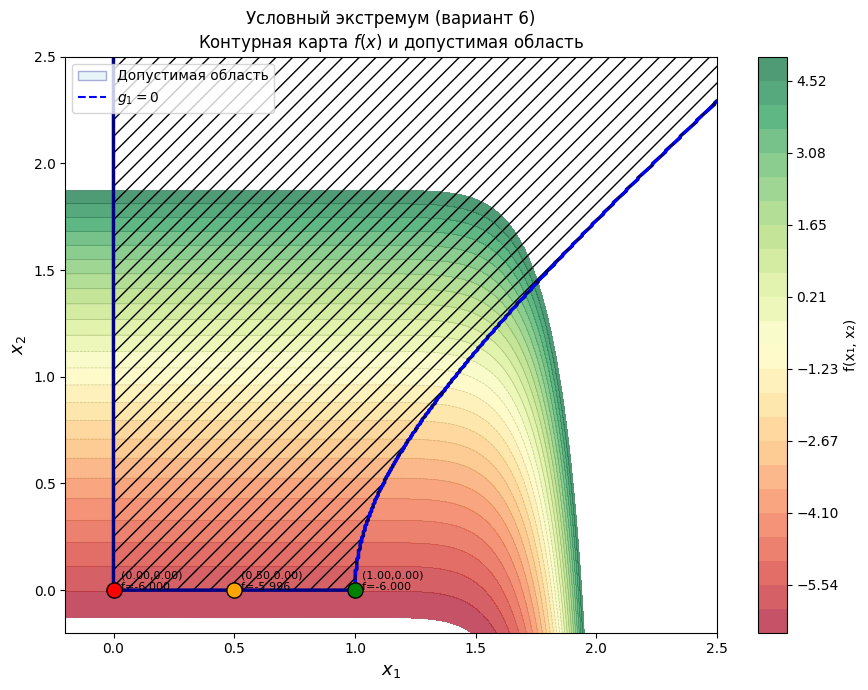

In [6]:
x1_grid = np.linspace(-0.2, 2.5, 400)
x2_grid = np.linspace(-0.2, 2.5, 400)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
F = (X1**2 - X1)**4 + (X2 + 2)**2 - 10

# Маска допустимой области
feasible = (X1**2 - X2**2 - 1 <= 0) & (X1 >= 0) & (X2 >= 0)

fig, ax = plt.subplots(figsize=(9, 7))

# Линии уровня объективной функции
levels = np.linspace(-6.5, 5, 25)
cs = ax.contourf(X1, X2, F, levels=levels, cmap='RdYlGn', alpha=0.7)
plt.colorbar(cs, ax=ax, label='f(x₁, x₂)')
ax.contour(X1, X2, F, levels=levels, colors='gray', linewidths=0.5, alpha=0.4)

# Заштриховка допустимой области
ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5],
            colors=['none'], hatches=['//'], alpha=0)
ax.contour(X1, X2, feasible.astype(float), levels=[0.5],
           colors=['navy'], linewidths=2.5)

# Граница g1: x1²-x2²=1 (гипербола)
x1_line = np.linspace(1.0, 2.5, 300)
x2_hyp  = np.sqrt(np.maximum(x1_line**2 - 1, 0))
ax.plot(x1_line, x2_hyp, 'b--', lw=2, label='$g_1: x_1^2-x_2^2=1$')

# ККТ-кандидаты
colors_pt = ['red','orange','green','purple']
for i, row in df_cand.iterrows():
    ax.scatter(row['x1'], row['x2'], s=120, c=colors_pt[i % len(colors_pt)],
               zorder=5, edgecolors='black')
    ax.annotate(f"  ({row['x1']:.2f},{row['x2']:.2f})\n  f={row['f(x)']:.3f}",
                (row['x1'], row['x2']), fontsize=8)

ax.set_xlim(-0.2, 2.5); ax.set_ylim(-0.2, 2.5)
ax.set_xlabel('$x_1$', fontsize=13); ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('Условный экстремум (вариант 6)\nКонтурная карта $f(x)$ и допустимая область', fontsize=12)
ax.legend(loc='upper right')
feasible_patch = mpatches.Patch(edgecolor='navy', facecolor='lightblue', alpha=0.3, label='Допустимая область')
ax.legend(handles=[feasible_patch,
                   plt.Line2D([],[],color='b',linestyle='--',label='$g_1=0$')])

plt.tight_layout()
fig.savefig(ART / 'conditional_extremum.png', dpi=150, bbox_inches='tight')
plt.show()


## Выводы

### Задача (вариант 6):
$f(x) = (x_1^2-x_1)^4 + (x_2+2)^2 - 10 \to \text{extr}$ при $x_1\ge0,\ x_2\ge0,\ x_1^2-x_2^2\le1$

### ККТ-точки на активной границе $g_3=0$ ($x_2=0$):
| Точка | $\lambda_3$ | $f(x)$ | Тип |
|---|---|---|---|
| $(0,\ 0)$ | 4 | −6 | локальный минимум |
| $(0.5,\ 0)$ | 4 | ≈−5.996 | не минимум (d²L < 0) |
| $(1,\ 0)$ | 4 | −6 | локальный минимум |

### Анализ:
- Точки $(0,0)$ и $(1,0)$ удовлетворяют необходимым и достаточным условиям 1-го порядка (все $\lambda_j\ge0$) и достаточным условиям 2-го порядка ($d^2L > 0$).
- Точка $(0.5,0)$: удовлетворяет условиям 1-го порядка, но $d^2L < 0$ — локальный максимум на $x_2=0$.
- **Глобальный минимум** $f(x^*)=-6$ достигается в точках $(0,0)$ и $(1,0)$.
- scipy подтверждает результат: $\min f = -6$.
